In [2]:
from google.colab import drive
import sys

# Mount Google Drive
drive.mount('/content/drive')

# Add the folder containing data_utils.py to the system path
sys.path.append('/content/drive/MyDrive/data')


Mounted at /content/drive


In [9]:
!pip install keras-tuner

In [10]:
# Standard libraries
import os
import cv2
import sys
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Metrics and evaluation
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

# Keras Tuner
from keras_tuner import HyperParameters
from keras_tuner.tuners import RandomSearch

# Custom utility functions
from data_utils import load_sample_dataframe_from_dir, load_dataset_from_df, load_dataset_from_dir


# Data Import

In [18]:
# Use Kaggle data as base

# --- Paths ---
normal_data_path = '/content/drive/MyDrive/data/chest_xray/train/NORMAL'
pneumonia_data_path = '/content/drive/MyDrive/data/chest_xray/train/PNEUMONIA'
test_data_path = '/content/drive/MyDrive/data/chest_xray/test'

# --- Build and split DataFrames ---
train_df = pd.DataFrame(columns=['filename', 'class'])
train_df = load_sample_dataframe_from_dir(train_df, normal_data_path, 'NORMAL', sample_size=1341, seed=42)
train_df = load_sample_dataframe_from_dir(train_df, pneumonia_data_path, 'PNEUMONIA', sample_size=3875, seed=42)

# Stratified train/val split
search_df, val_df = train_test_split(train_df, test_size=0.2, stratify=train_df['class'], random_state=42)

# --- Create datasets ---
search_ds = load_dataset_from_df(search_df, "filename", "class", img_size=(224, 224), batch_size=32)
val_ds = load_dataset_from_df(val_df, "filename", "class", img_size=(224, 224), batch_size=32)
test_ds = load_dataset_from_dir(test_data_path, img_size=(224, 224), batch_size=32, gaussian_blur=False)


Found 4172 validated image filenames belonging to 2 classes.
Found 1044 validated image filenames belonging to 2 classes.
Found 624 images belonging to 2 classes.


## CNN Model Search
The function below defines a baseline Convolutional Neural Network (CNN) architecture, which serves as a benchmark to evaluate how different data configurations impact model performance.

This model consists of two configurable convolutional blocks followed by max-pooling layers to extract and downsample key features. A fully connected dense layer captures higher-level patterns before passing to the final classification layer.

The output layer uses a sigmoid activation to assign probabilities for Normal vs Pneumonia classification in this binary setup.

In [12]:
def build_model(hp):
    input_shape = (224, 224, 1)
    num_classes = 1

    model = models.Sequential()

    # Conv Block 1
    model.add(layers.Conv2D(
        filters=hp.Int('conv1_filters', min_value=32, max_value=64, step=16),
        kernel_size=(3, 3),
        padding='same',
        input_shape=input_shape
    ))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))

    # Conv Block 2
    model.add(layers.Conv2D(
        filters=hp.Int('conv2_filters', min_value=64, max_value=128, step=32),
        kernel_size=(3, 3),
        padding='same'
    ))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))

    # Flatten + Dense
    model.add(layers.Flatten())
    model.add(layers.Dense(
        units=hp.Int('dense_units', min_value=64, max_value=256, step=64),
        kernel_regularizer=regularizers.l2(0.001)
    ))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(hp.Float('dropout_rate', 0.3, 0.5, step=0.1)))

    # Output
    model.add(layers.Dense(num_classes, activation='sigmoid'))

    # Compile
    lr = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy', 'precision', 'recall']
    )

    return model


In [13]:
# Define Model Tuner

tuner = RandomSearch(
    hypermodel=build_model,
    objective='val_accuracy',
    max_trials=10,  # Number of hyperparameter combinations to try
    executions_per_trial=1,  # Run each trial once (can increase for stability)
    directory='/content/drive/MyDrive/data/tuner_results',
    project_name='pneumonia_cnn'
)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
# Optional: Stop early if no improvement
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Start tuning search
tuner.search(
    search_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stopping]
)


Trial 10 Complete [00h 10m 51s]
val_accuracy: 0.9252873659133911

Best val_accuracy So Far: 0.9818007946014404
Total elapsed time: 01h 46m 18s


In [15]:
# Display the best hyperparameters
tuner.results_summary()


Results summary
Results in /content/drive/MyDrive/data/tuner_results/pneumonia_cnn
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 05 summary
Hyperparameters:
conv1_filters: 64
conv2_filters: 96
dense_units: 256
dropout_rate: 0.4
learning_rate: 0.0001
Score: 0.9818007946014404

Trial 07 summary
Hyperparameters:
conv1_filters: 64
conv2_filters: 64
dense_units: 64
dropout_rate: 0.4
learning_rate: 0.0001
Score: 0.9808428883552551

Trial 03 summary
Hyperparameters:
conv1_filters: 64
conv2_filters: 64
dense_units: 64
dropout_rate: 0.5
learning_rate: 0.0001
Score: 0.9789271950721741

Trial 02 summary
Hyperparameters:
conv1_filters: 48
conv2_filters: 96
dense_units: 192
dropout_rate: 0.3
learning_rate: 0.0001
Score: 0.975095808506012

Trial 01 summary
Hyperparameters:
conv1_filters: 32
conv2_filters: 96
dense_units: 192
dropout_rate: 0.4
learning_rate: 0.01
Score: 0.9568965435028076

Trial 06 summary
Hyperparameters:
conv1_filters: 48
conv2_filters: 96
dense_unit

In [16]:
# Get the best model from the tuner
best_model = tuner.get_best_models(num_models=1)[0]

# Optional: Show best hyperparameters
best_hps = tuner.get_best_hyperparameters(1)[0]
print("Best hyperparameters:")
for param in best_hps.values:
    print(f"{param}: {best_hps.get(param)}")


Best hyperparameters:
conv1_filters: 64
conv2_filters: 96
dense_units: 256
dropout_rate: 0.4
learning_rate: 0.0001


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## Model Training and Evaluation
The following function trains the CNN model that is defined above. Once the model is trained, the metrics (accuracy, precision, recall and f1) are extracted from the model. The precision and recall metrics are important in addition to accuracy because of the large class imbalance in this dataset. These are good metrics to compare model performance against different input data configurations. These metrics are written to a named csv file that can be referenced later, and also used for plotting the results.

In [ ]:
def train_and_evaluate(model, train_ds, val_ds, test_ds, test_description="example_test"):
    results_path = f"{test_description}_results.csv"

    # Callbacks for training
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=5, verbose=1)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=30,
        callbacks=[lr_scheduler, early_stopping]
    )

    # Reset test_ds if applicable
    if hasattr(test_ds, 'reset'):
        test_ds.reset()

    # Predictions
    y_true, y_pred = [], []
    for images, labels in test_ds:
        predictions = model.predict(images, verbose=0)
        binary_preds = (predictions > 0.6).astype(int).flatten()
        y_true.extend(labels.astype(int))
        y_pred.extend(binary_preds)

    # Metrics
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    report = classification_report(y_true, y_pred, output_dict=True)
    class_0_precision = report['0']['precision']
    class_0_recall = report['0']['recall']
    class_1_precision = report['1']['precision']
    class_1_recall = report['1']['recall']

    results_df = pd.DataFrame({
        'Accuracy': [accuracy],
        'Precision': [precision],
        'Recall': [recall],
        'F1 Score': [f1],
        'Class_0_Precision': [class_0_precision],
        'Class_0_Recall': [class_0_recall],
        'Class_1_Precision': [class_1_precision],
        'Class_1_Recall': [class_1_recall]
    })

    results_df.to_csv(results_path, index=False)
    print("Metrics saved to", results_path)
    print(classification_report(y_true, y_pred))
    return history, y_true, y_pred, results_df


## Results
The following function creates 3 different plots to show the metrics for training and validation. The first plot is the training and validation accuracy comparison. The second plot is the loss function for training and testing and the final plot shows the recall metrics.

In [ ]:
# Function to visualize results
def plot_results(history, y_true, y_pred, test_description):
    # accuracy metric
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.legend()
    plt.title('Training & Validation Accuracy')
    plt.savefig(f"{test_description}_accuracy.png")

    # loss function
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.legend()
    plt.title('Training & Validation Loss')
    plt.savefig(f"{test_description}_loss.png")

    # recall metric
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.plot(history.history['recall'], label='Train Recall')
    plt.plot(history.history['val_recall'], label='Val Recall')
    plt.legend()
    plt.title('Training & Validation Recall')
    plt.savefig(f"{test_description}_recall.png")

    plt.show()

### Run CNN
The remaining code blocks run the functions defined above. To change the data being processed, the different settings should be changed here. The dataset path as well as the training, validation and testing datasets can be loaded according to desired test.

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
326/326 ━━━━━━━━━━━━━━━━━━━━ 67s 177ms/step - accuracy: 0.8921 - loss: 0.6178 - precision: 0.9336 - recall: 0.9174 - val_accuracy: 0.5000 - val_loss: 2.0015 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/30
326/326 ━━━━━━━━━━━━━━━━━━━━ 56s 171ms/step - accuracy: 0.9582 - loss: 0.4552 - precision: 0.9715 - recall: 0.9723 - val_accuracy: 0.6875 - val_loss: 0.8717 - val_precision: 0.6154 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/30
326/326 ━━━━━━━━━━━━━━━━━━━━ 56s 172ms/step - accuracy: 0.9639 - loss: 0.3892 - precision: 0.9807 - recall: 0.9710 - val_accuracy: 1.0000 - val_loss: 0.3741 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/30
326/326 ━━━━━━━━━━━━━━━━━━━━ 56s 172ms/step - accuracy: 0.9620 - loss: 0.3501 - precision: 0.9745 - recall: 0.9744 - val_accuracy: 0.6250 - val_loss: 0.8342 - val_precision: 0.5714 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 5/30
326/326 ━━━━━━━━━━━━━━━━━

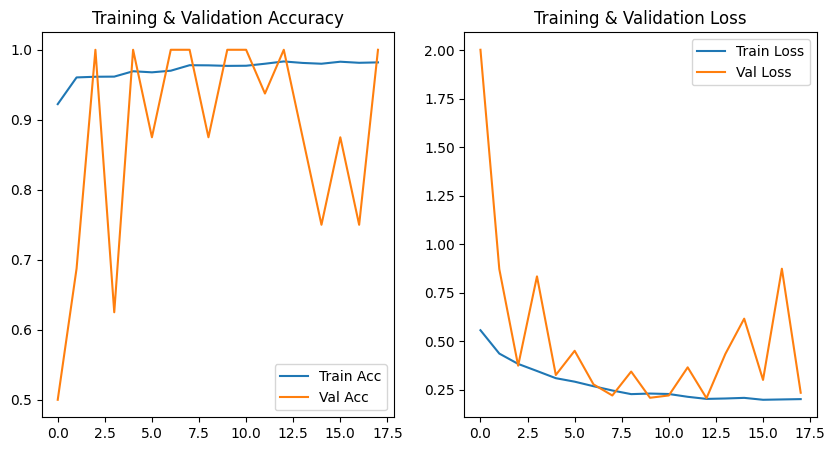

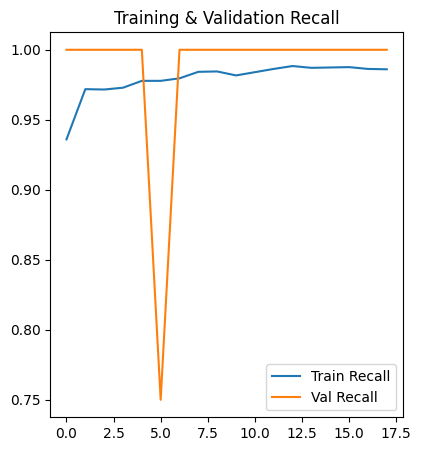

In [ ]:
# Evaluate the best model from the tuner
test_description = "tuned_cnn_final"

history, y_true, y_pred, results_df = train_and_evaluate(
    model=best_model,
    train_ds=search_ds,
    val_ds=val_ds,
    test_ds=test_ds,
    test_description=test_description
)

plot_results(history, y_true, y_pred, test_description)


## Balanced Data
The next test uses only the kaggle dataset, but balances it so there is not a majority class like what exists in the actual dataset.

In [ ]:
# Balance the training data
balanced_train_df = balance_data('/content/drive/MyDrive/data/chest_xray/train')

# Split into new search/val sets
search_df_bal, val_df_bal = train_test_split(
    balanced_train_df,
    test_size=0.2,
    stratify=balanced_train_df['class'],
    random_state=42
)

# Create balanced datasets
train_ds_bal = search_ds_bal = load_dataset_from_df(search_df_bal, "filename", "class", img_size=(224, 224), batch_size=32)
val_ds_bal = load_dataset_from_df(val_df_bal, "filename", "class", img_size=(224, 224), batch_size=32)

# Evaluate best model on balanced data
test_description = "tuned_cnn_balanced"

history_bal, y_true_bal, y_pred_bal, results_df_bal = train_and_evaluate(
    model=best_model,
    train_ds=train_ds_bal,
    val_ds=val_ds_bal,
    test_ds=test_ds,
    test_description=test_description
)

plot_results(history_bal, y_true_bal, y_pred_bal, test_description)



Found 2682 validated image filenames belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 2 invalid image filename(s) in x_col="filename". These filename(s) will be ignored.
  warnings.warn(


## Different Tests to Try
This section will be used to track the different tests preformed to ensure model training and data testing is going well and we are able to fully understand the impact synthetic data makes on the accuracy and precision and recall of the CNN model for classifying Pneumonia and Normal lungs.

- [ ] Full Kaggle Dataset only (Base CNN)
- [ ] Full Kaggle Dataset only (Transfer learning)
- [ ] Balanced Kaggle Dataset only (Base CNN)
- [ ] Balanced Kaggle Dataset only (Transfer learning)
- [ ] Only Pneumonia Synthetic -- Pawan (Base CNN)
- [ ] Only Pneumonia Synthetic -- Pawan (Transfer Learning)
- [ ] Only Normal Synthetic -- Pawan (Base CNN)
- [ ] Only Normal Synthetic -- Pawan (Transfer Learning)
- [ ] Balanced Synthetic Only -- Pawan (Base CNN)
- [ ] Balanced Synthetic Only -- Pawan (Transfer Learning)
- [ ] Only Pneumonia Synthetic -- Ned (Base CNN)
- [ ] Only Pneumonia Synthetic -- Ned (Transfer Learning)
[ ] Only Normal Synthetic -- Ned (Base CNN)
[ ] Only Normal Synthetic -- Ned (Transfer Learning)
[ ] Balanced Synthetic Only -- Ned (Base CNN)
[ ] Balanced Synthetic Only -- Ned (Transfer Learning)
[ ] Balanced Synthetic and Kaggle Dataset (Base CNN)
[ ] Balanced Synthetic and Kaggle Dataset (Transfer Learning)

## AC GAN
The following sections loads the ARC GAN images and trains the CNN model using these images. These images are also used for the validation. The test images are from the Kaggle Dataset.

In [ ]:
# --- Paths ---
acgan_data_path = '/content/drive/MyDrive/data/ACGAN_128'
test_data_path = '/content/drive/MyDrive/data/chest_xray/test'

# --- Build full dataframe from ACGAN synthetic data ---
acgan_df = balance_data(acgan_data_path)  # Balanced already (1000 each, just standardizing flow)

# --- Split into train and val ---
train_df_acgan, val_df_acgan = train_test_split(
    acgan_df,
    test_size=0.2,
    stratify=acgan_df['class'],
    random_state=42
)

# --- Create datasets ---
train_ds_acgan = load_dataset_from_df(train_df_acgan, "filename", "class", img_size=(224, 224), batch_size=32)
val_ds_acgan = load_dataset_from_df(val_df_acgan, "filename", "class", img_size=(224, 224), batch_size=32)
test_ds = load_dataset_from_dir(test_data_path, img_size=(224, 224), batch_size=32, gaussian_blur=False)


Dataset successfully split into training and validation sets!
Found 1600 images belonging to 2 classes.
Found 400 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


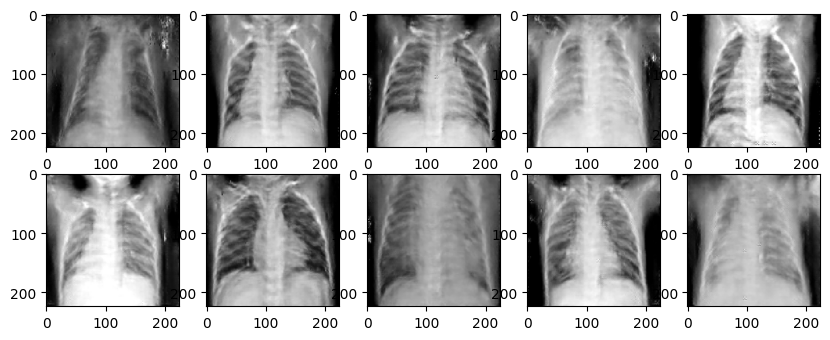

In [ ]:
# Visualize first 10 synthetic images from ACGAN training set
images, labels = next(iter(train_ds_acgan))
plt.figure(figsize=(10, 10))
for i in range(10):
    ax = plt.subplot(5, 5, i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f"Label: {int(labels[i])}")
    plt.axis("off")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 99ms/step - accuracy: 0.7449 - loss: 0.8500 - precision: 0.7611 - recall: 0.6582 - val_accuracy: 0.5000 - val_loss: 1.1348 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - accuracy: 0.9516 - loss: 0.5459 - precision: 0.9535 - recall: 0.9499 - val_accuracy: 0.5000 - val_loss: 1.5423 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - accuracy: 0.9678 - loss: 0.4721 - precision: 0.9664 - recall: 0.9688 - val_accuracy: 0.5000 - val_loss: 1.8492 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - accuracy: 0.9738 - loss: 0.4546 - precision: 0.9765 - recall: 0.9732 - val_accuracy: 0.5000 - val_loss: 1.5818 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step

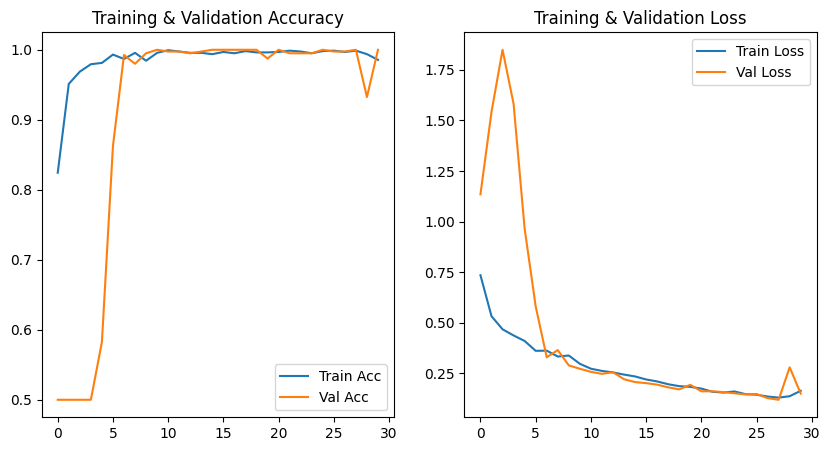

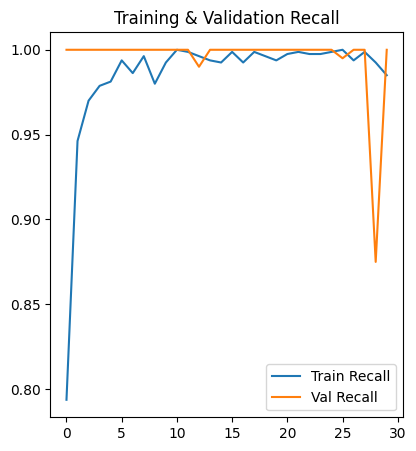

In [ ]:
# Train and evaluate using synthetic (ACGAN) training data
test_description = "tuned_cnn_acgan"

history_acgan, y_true_acgan, y_pred_acgan, results_df_acgan = train_and_evaluate(
    model=best_model,
    train_ds=train_ds_acgan,
    val_ds=val_ds_acgan,
    test_ds=test_ds,
    test_description=test_description
)

plot_results(history_acgan, y_true_acgan, y_pred_acgan, test_description)


## Style GAN
The following section uses the synthetically generated images from the Style GAN. The train and validation sets are all synthetic images, while the test data comes from the original data in Kaggle. This is to help compare performance of the model on the same tests.

In [ ]:
# --- Paths ---
stylegan_data_path = '/content/drive/MyDrive/data/STYLEGAN_128'
test_data_path = '/content/drive/MyDrive/data/chest_xray/test'

# --- Build full dataframe from STYLEGAN synthetic data ---
stylegan_df = balance_data(stylegan_data_path)

# --- Split into train and val ---
train_df_stylegan, val_df_stylegan = train_test_split(
    stylegan_df,
    test_size=0.2,
    stratify=stylegan_df['class'],
    random_state=42
)

# --- Create datasets ---
train_ds_stylegan = load_dataset_from_df(train_df_stylegan, "filename", "class", img_size=(224, 224), batch_size=32)
val_ds_stylegan = load_dataset_from_df(val_df_stylegan, "filename", "class", img_size=(224, 224), batch_size=32)
test_ds = load_dataset_from_dir(test_data_path, img_size=(224, 224), batch_size=32, gaussian_blur=False)


Dataset successfully split into training and validation sets!
Found 1600 images belonging to 2 classes.
Found 400 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


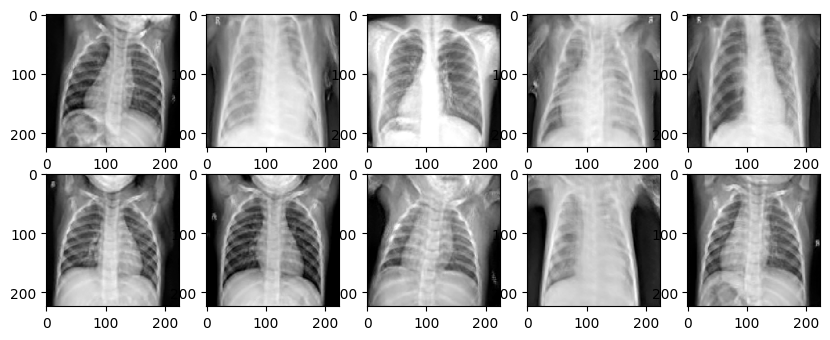

In [ ]:
# Visualize first 10 synthetic images from STYLEGAN training set
images, labels = next(iter(train_ds_stylegan))
plt.figure(figsize=(10, 10))
for i in range(10):
    ax = plt.subplot(5, 5, i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f"Label: {int(labels[i])}")
    plt.axis("off")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 116ms/step - accuracy: 0.8227 - loss: 0.7492 - precision: 0.8342 - recall: 0.8156 - val_accuracy: 0.5000 - val_loss: 2.5695 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - accuracy: 0.9576 - loss: 0.5157 - precision: 0.9645 - recall: 0.9522 - val_accuracy: 0.5000 - val_loss: 2.7339 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - accuracy: 0.9733 - loss: 0.4579 - precision: 0.9841 - recall: 0.9626 - val_accuracy: 0.5000 - val_loss: 2.0427 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - accuracy: 0.9849 - loss: 0.4102 - precision: 0.9881 - recall: 0.9818 - val_accuracy: 0.5000 - val_loss: 1.5291 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━

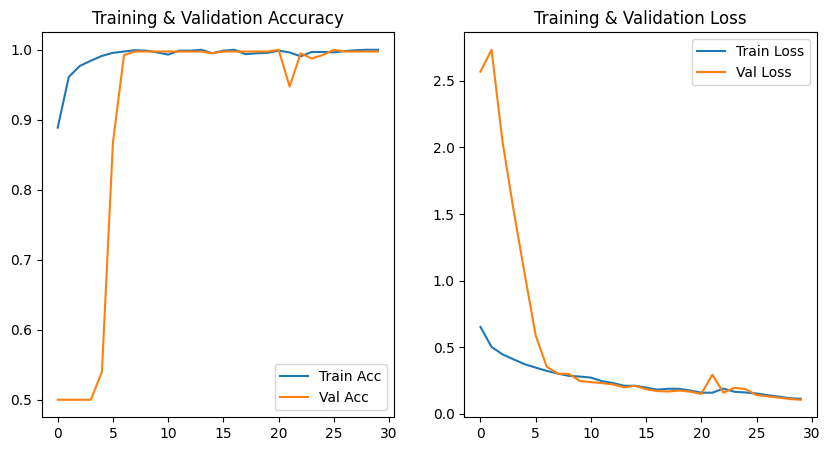

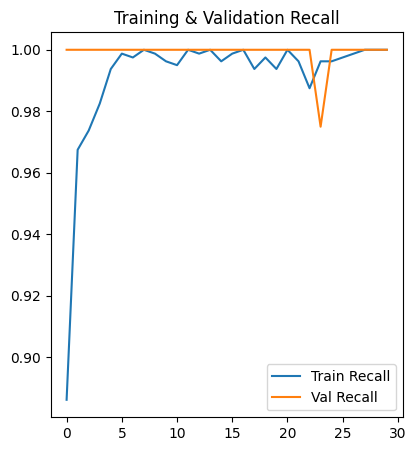

In [ ]:
# Train and evaluate using STYLEGAN-generated synthetic data
test_description = "tuned_cnn_stylegan"

history_stylegan, y_true_stylegan, y_pred_stylegan, results_df_stylegan = train_and_evaluate(
    model=best_model,
    train_ds=train_ds_stylegan,
    val_ds=val_ds_stylegan,
    test_ds=test_ds,
    test_description=test_description
)

plot_results(history_stylegan, y_true_stylegan, y_pred_stylegan, test_description)
